<a href="https://colab.research.google.com/github/iabad5-del/upc-ia/blob/main/Preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EXPLORACIÓ I PROCESSAMENT DE DADES**

---



In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("/content/titanic.csv") # https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv

## 1. Dataset original

Atributs del dataset:


*   **survived**: Identifica si el passatger va sobreviure (1) o no (0)
*   **pclass**: Classe de tiquet del passatges: primera (1), segona (2) o tercera (3)
*   **sex**: male/female
*   **age**: Edat en anys
*   **sibsp**: Nombre de germans i dona/marit que viatjaven també al Titanic
*   **parch**: Nombre de pares i fills que viatjaven també al Titanic
*   **fare**: Tarifa del bitllet del passatger
*   **embarked**: Port on va embarcar el passatger: C-Cherbourg, S-Southampton o Q-Queenstown
*   **class**: Classe del viatger: First, Second o Third.
*   **who**: man/woman
*   **adult_male**: Identifica si el passatger és un home adult (True) o no (False)
*   **deck**: Coberta del camarot del passatger: A, B, C, D, E, F o G.
*   **embark_town**: Ciutat d'embarcament: Cherbourg, Southampton o Queenstown.
*   **alive**: Identifica si el passatger va viure (1) o no (0)
*   **alone**: Identifica si el passatger viatjava sol (True) o acompanyat (False)


In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
missing_values = df.isna().sum() # Nombre total de missing values
duplicates = df.duplicated().sum() # Nombre total de files repetides
columns = df.columns # Noms de les columnes

print(f"Noms de les columnes: \n{columns}")
print('----------------------------------')
print(f"Nombre total de missing values: \n{missing_values}")
print('----------------------------------')
print(f"Nombre total de files repetides: {duplicates}")

Noms de les columnes: 
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
----------------------------------
Nombre total de missing values: 
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
----------------------------------
Nombre total de files repetides: 107


In [ ]:
df['sex'].unique() # Valors únics de la columna 'deck'

array(['male', 'female'], dtype=object)



---



## 2. Eliminació de files i columnes

La columna 'deck' té 688 missing values d'un total de 891 files. És a dir, un 77% de les dades falten. Així doncs, eliminarem la columna.

In [4]:
df = df.drop('deck', axis=1)

A més, hem vist que hi ha 107 files repetides. Aquestes també les eliminarem.

In [ ]:
df = df.drop_duplicates()
print(f"Nombre total de files repetides: {df.duplicated().sum()}")

Nombre total de files repetides: 0


A part, també hi ha molta informació redundant, moltes columnes que repeteixen les mateixes dades:


1.   **survived** i **alive**
2.   **pclass** i **class**
3.   **sex** i **who** presenten quasi bé la mateixa dada, però **who** afegeix més informació, ja que inclou la categoria *child*. A més, **adult_male** també mostra el mateix.
4.   **embarked** i **embark_town**



In [ ]:
df = df.drop(['alive', 'pclass', 'sex', 'adult_male', 'embark_town'], axis=1)

In [ ]:
df.shape

(780, 9)

Fixem-nos ara en les columnes **sibsp**, **parch** i **alone**. Les dues primeres son de tipus enter i l'última booleà. Per a construir l'atribut **alone** se suma els acompanyants del viatger (**sibsp** i **parch**), de manera que si és 0 **alone** és True i si és major a 0 **alone** és False. Llavors, per tal de simplificar les dades, eliminarem les columnes **sibsp** i **parch**.

In [ ]:
df = df.drop(['sibsp', 'parch'], axis=1)

In [ ]:
df.head()

,survived,age,fare,embarked,class,who,alone
0,0,22.0,7.2500,S,Third,man,False
1,1,38.0,71.2833,C,First,woman,False
2,1,26.0,7.9250,S,Third,woman,True
3,1,35.0,53.1000,S,First,woman,False
4,0,35.0,8.0500,S,Third,man,True


In [ ]:
missing_values = df.isna().sum() # Nombre total de missing values
duplicates = df.duplicated().sum() # Nombre total de files repetides
columns = df.columns # Noms de les columnes

print(f"Noms de les columnes: \n{columns}")
print('----------------------------------')
print(f"Nombre total de missing values: \n{missing_values}")
print('----------------------------------')
print(f"Nombre total de files repetides: {duplicates}")

Noms de les columnes: 
Index(['survived', 'age', 'fare', 'embarked', 'class', 'who', 'alone'], dtype='object')
----------------------------------
Nombre total de missing values: 
survived      0
age         104
fare          0
embarked      2
class         0
who           0
alone         0
dtype: int64
----------------------------------
Nombre total de files repetides: 2


Ara, tractarem els valors NaN de les variables *age* i *embarked*. Les files amb valors nul d'*embarked* les eliminarem, ja que n'hi ha només dues. En canvi, els missing values d'*age* els imputarem. Hi ha diverses maneres d'imputar aquests valors, ara en veurem dues: omplir-los amb la mitjana i interpolar-los de manera lineal.

Proveu els dos mètodes i observeu com l'histograma de la variable canvia. Descomenteu una de les dues línies (eliminant el símbol #) cada vegada.

<Axes: xlabel='age', ylabel='Count'>

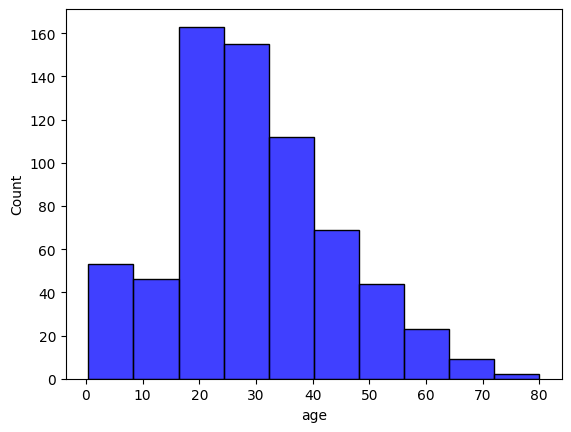

In [ ]:
sns.histplot(df['age'], bins=10, color='blue')

In [ ]:
# df['age'] = df['age'].interpolate(method='linear')
# df['age'] = df['age'].fillna(df['age'].mean())

<Axes: xlabel='age', ylabel='Count'>

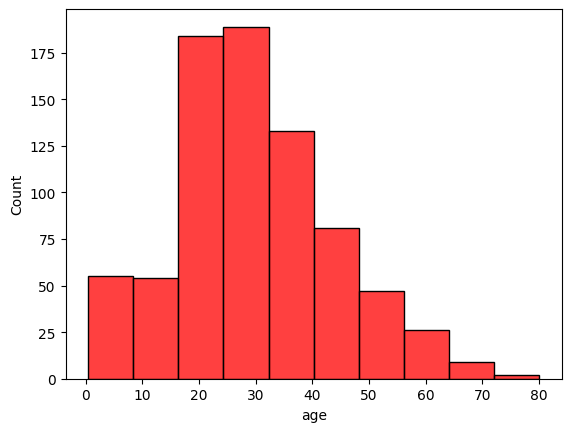

In [ ]:
sns.histplot(df['age'], bins=10, color='red')

In [ ]:
missing_values = df.isna().sum() # Nombre total de missing values

print(f"Nombre total de missing values: \n{missing_values}")

Nombre total de missing values: 
survived    0
age         0
fare        0
embarked    2
class       0
who         0
alone       0
dtype: int64


In [ ]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])



---



## 3. Anàlisi de les dades

### 3.1. Anàlisi univariada (1 variable)

**Histogrames**

<Axes: xlabel='age', ylabel='Count'>

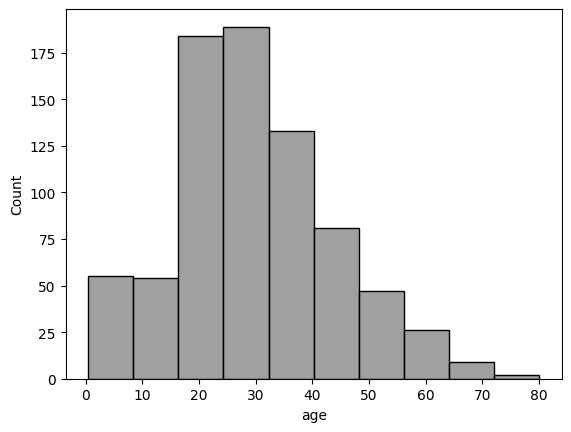

In [ ]:
sns.histplot(df['age'], bins=10, color='grey')

<Axes: xlabel='fare', ylabel='Count'>

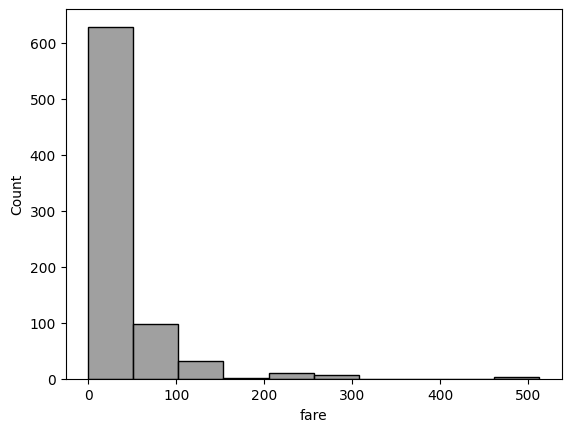

In [ ]:
sns.histplot(df['fare'], bins=10, color='grey')

**Gràfics de barres**

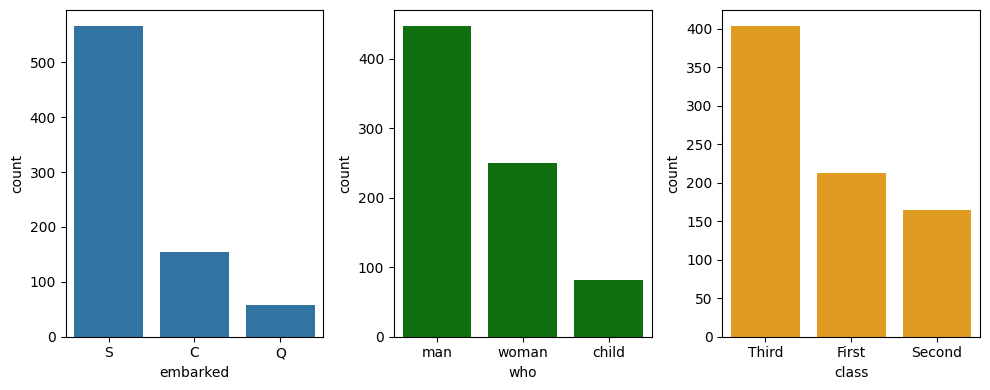

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.countplot(df, x="embarked", ax=axes[0])
axes[0].set_title('')

sns.countplot(df, x="who", ax=axes[1], color='green')
axes[1].set_title('')

sns.countplot(df, x="class", ax=axes[2], color='orange')
axes[2].set_title('')

plt.tight_layout()
plt.show()

**Gràfics de densitat**

<Axes: ylabel='Density'>

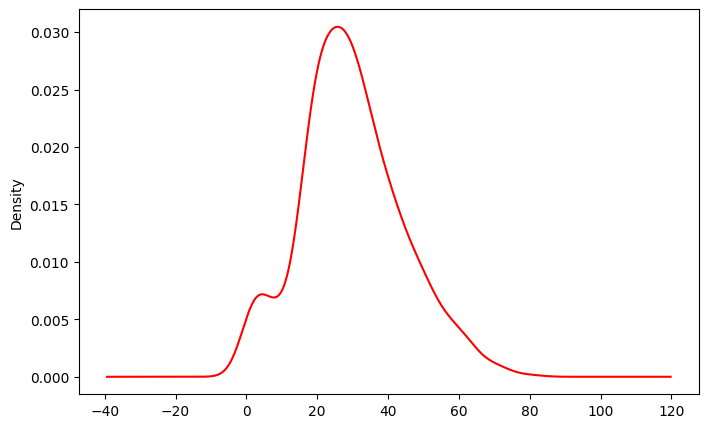

In [ ]:
df['age'].plot.kde(figsize=(8, 5), color='red')

<Axes: ylabel='Density'>

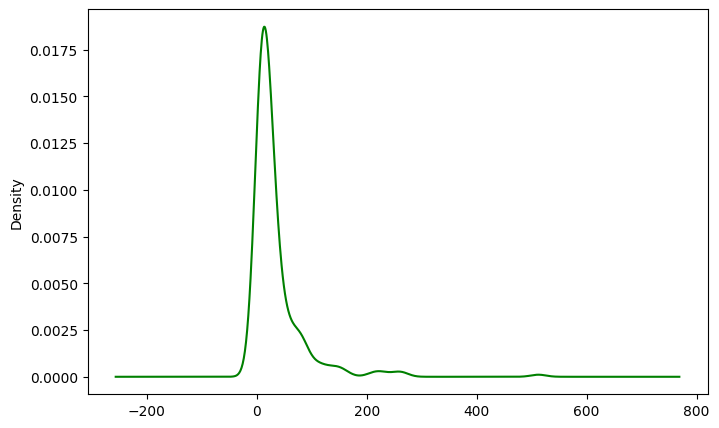

In [ ]:
df['fare'].plot.kde(figsize=(8, 5), color='green')

### 3.2. Anàlisi univariada (1 variable)

**Scatterplot**

<Axes: xlabel='age', ylabel='fare'>

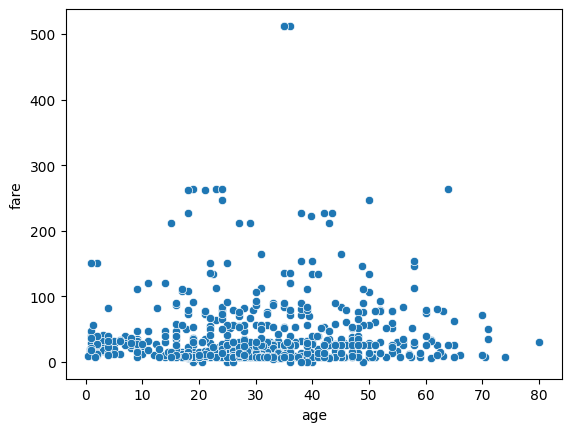

In [ ]:
sns.scatterplot(data=df, y="fare", x="age")

**Gràfics de barres**

<Axes: xlabel='who', ylabel='count'>

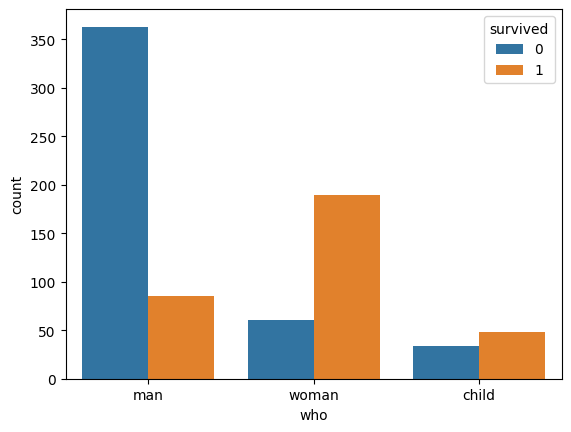

In [ ]:
sns.countplot(df, x='who', hue='survived')

<Axes: xlabel='class', ylabel='count'>

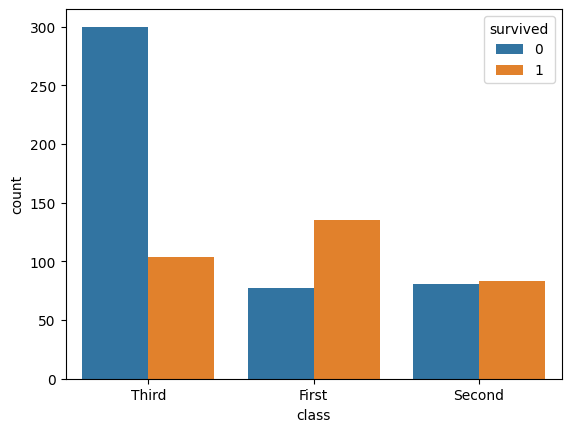

In [ ]:
sns.countplot(df, x='class', hue='survived')

<Axes: xlabel='who', ylabel='count'>

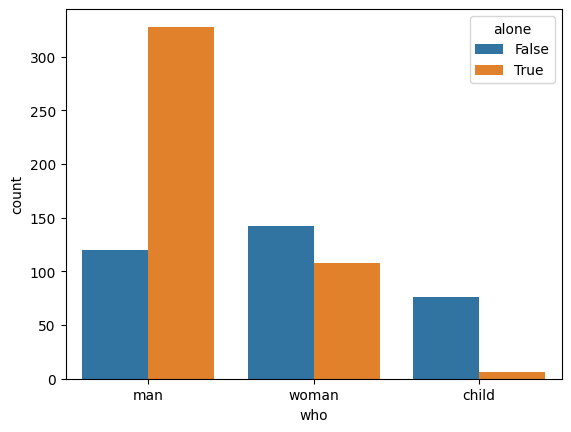

In [ ]:
sns.countplot(df, x='who', hue='alone')

<Axes: xlabel='survived', ylabel='count'>

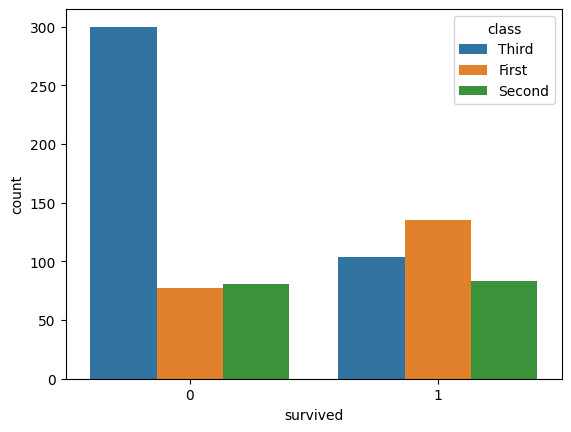

In [ ]:
sns.countplot(df, x='survived', hue='class')

**Gràfic de mosaic**

(<Figure size 640x480 with 3 Axes>,
 {('man', 'Third'): (0.0,
   np.float64(0.0),
   0.5686722518405686,
   np.float64(0.5521227530747397)),
  ('man', 'First'): (0.0,
   np.float64(0.5554340113528854),
   0.5686722518405686,
   np.float64(0.25721381267738885)),
  ('man', 'Second'): (0.0,
   np.float64(0.8159590823084201),
   0.5686722518405686,
   np.float64(0.18404091769157988)),
  ('woman', 'Third'): (0.5736227468900735,
   np.float64(0.0),
   0.3173394262503174,
   np.float64(0.3894039735099337)),
  ('woman', 'First'): (0.5736227468900735,
   np.float64(0.39271523178807943),
   0.3173394262503174,
   np.float64(0.35761589403973504)),
  ('woman', 'Second'): (0.5736227468900735,
   np.float64(0.7536423841059602),
   0.3173394262503174,
   np.float64(0.2463576158940397)),
  ('child', 'Third'): (0.8959126681898959,
   np.float64(0.0),
   0.10408733181010404,
   np.float64(0.6905184945889192)),
  ('child', 'First'): (0.8959126681898959,
   np.float64(0.6938297528670649),
   0.10408733181

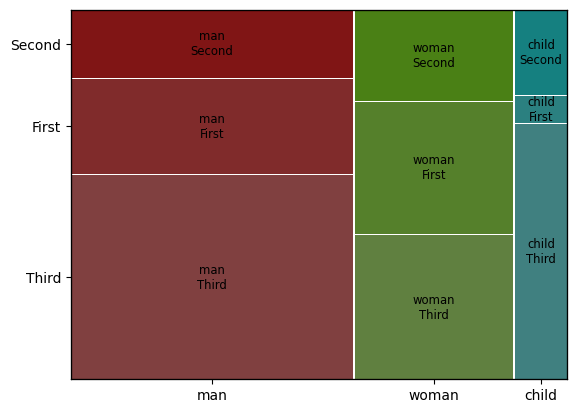

In [ ]:
mosaic(df, ['who', 'class'])

(<Figure size 640x480 with 3 Axes>,
 {('0', 'Third'): (0.0,
   np.float64(0.0),
   0.5842581961984948,
   np.float64(0.650683941120333)),
  ('0', 'First'): (0.0,
   np.float64(0.6539951993984787),
   0.5842581961984948,
   np.float64(0.16700887822088548)),
  ('0', 'Second'): (0.0,
   np.float64(0.8243153358975099),
   0.5842581961984948,
   np.float64(0.17568466410248995)),
  ('1', 'Third'): (0.5892333205766043,
   np.float64(0.0),
   0.41076667942339584,
   np.float64(0.3208424170128748)),
  ('1', 'First'): (0.5892333205766043,
   np.float64(0.3241536752910205),
   0.41076667942339584,
   np.float64(0.41647813746863555)),
  ('1', 'Second'): (0.5892333205766043,
   np.float64(0.7439430710378018),
   0.41076667942339584,
   np.float64(0.2560569289621981))})

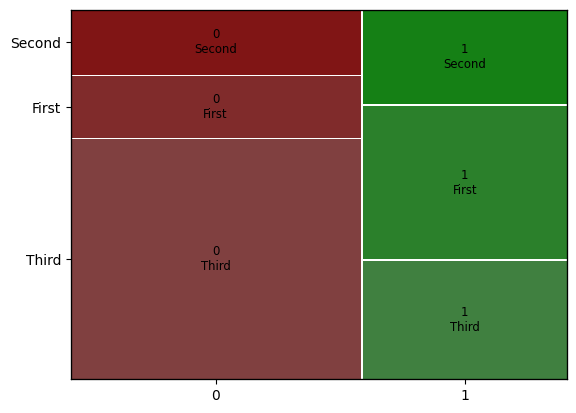

In [ ]:
mosaic(df, ['survived', 'class'])

**Gràfic de densitat**

Un gràfic de densitat és una representació visual de la distribució de dades numèriques contínues. Funciona com una versió suavitzada d'un histograma, utilitzant una corba de densitat (representació gràfica que mostra la distribució d'una variable contínua) en lloc de barres.

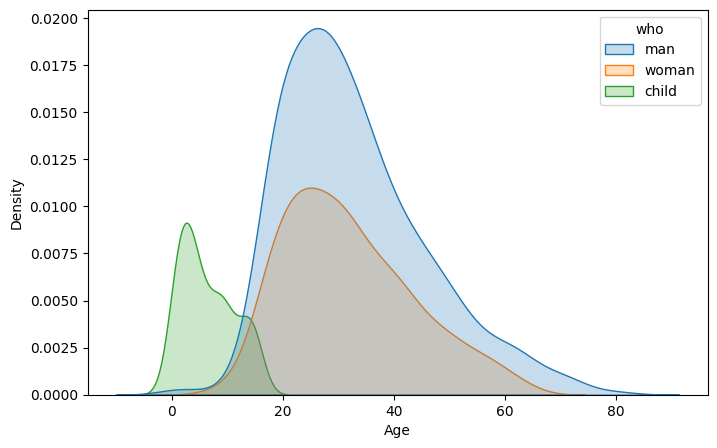

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='age', hue='who', fill=True)
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

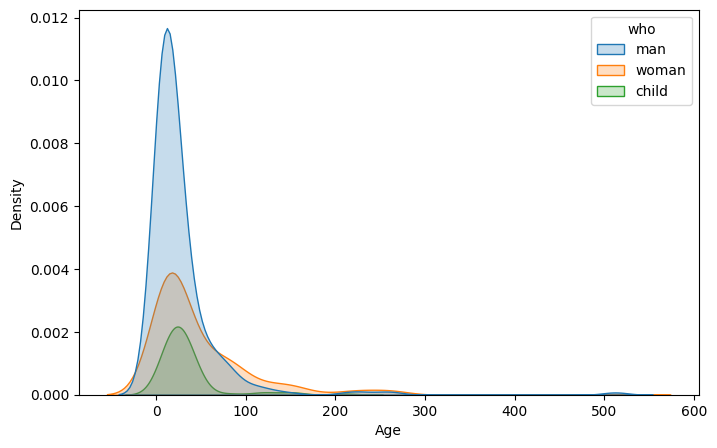

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='fare', hue='who', fill=True)
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

## 4. Outliers

Amb la funció *zscore* i la condició que aquesta sigui major a 3 podem veure els outliers d'una variable en concret.

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd

z = np.abs(stats.zscore(df['fare']))
print("Z-Score Values:\n", z)

outliers = df[z > 3]
print("Outliers:\n", outliers)

Z-Score Values:
 [5.28032665e-01 6.97956028e-01 5.15109040e-01 3.49816541e-01
 5.12715776e-01 5.04898419e-01 3.26123229e-01 2.63337675e-01
 4.53682571e-01 9.11030866e-02 3.47101913e-01 1.58512716e-01
 5.12715776e-01 6.80473393e-02 5.16464585e-01 3.60504191e-01
 1.09211479e-01 4.17942525e-01 3.22211968e-01 5.28511318e-01
 1.69043077e-01 4.17942525e-01 5.13114015e-01 1.28449813e-02
 2.63337675e-01 6.58934017e-02 5.28511318e-01 4.36858532e+00
 5.15985932e-01 5.15668106e-01 1.36096448e-01 2.13846158e+00
 5.18459609e-01 4.65807803e-01 9.06409316e-01 3.28755819e-01
 5.28430904e-01 5.12715776e-01 3.22211968e-01 4.51607132e-01
 4.85432567e-01 2.64773634e-01 5.15668106e-01 1.29238022e-01
 5.15985932e-01 5.12715776e-01 3.70077246e-01 2.51769595e-01
 3.26041190e-01 9.30193227e-02 5.17502304e-01 8.02223836e-01
 1.69043077e-01 5.19818694e-01 1.28449813e-02 4.65807803e-01
 5.28430904e-01 1.35537382e-01 2.31110651e-01 5.28430904e-01
 8.64846937e-01 9.31379674e-01 1.32665465e-01 1.36096448e-01
 3.7494

Amb els resultats obtinguts en l'atribut *fare*, veiem que hi ha algunes files que es consideren outliers. Però, un bitllet de primera classe amb aquests preus tan elevats és un outlier? Aquí és on entra la subjectivitat; tant si eliminem aquests valors com si no ho fem i ho justifiquem es pot considerar un moviment vàlid.

**Boxplot**

La gràfica boxplot és una altra manera d'dentificar outliers a les dades. A més, podem veure'ls en relació les diferents categories.

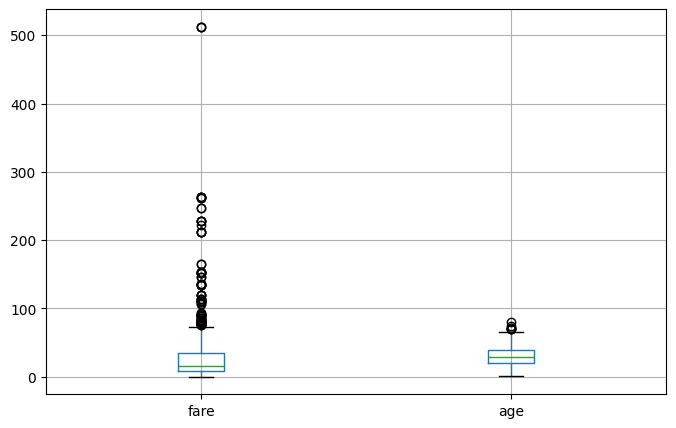

In [ ]:
boxplot = df.boxplot(column=['fare', 'age'], figsize=(8, 5))

<Axes: xlabel='fare', ylabel='class'>

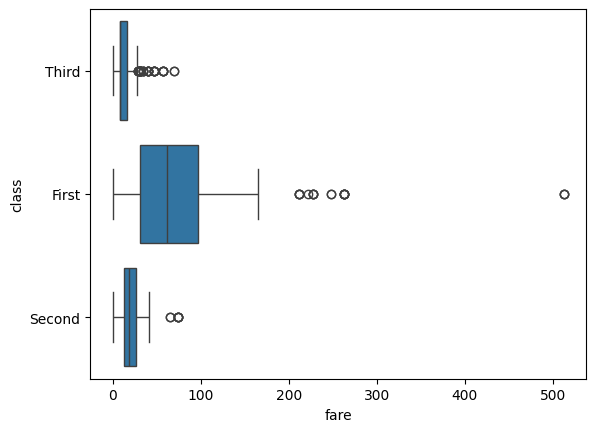

In [ ]:
sns.boxplot(data=df, x="fare", y="class")

# **ENCODING I ESTANDARDITZACIÓ**

Finalment, codificarem les variables numèriques i, després, estandarditzarem totes les dades per tal que els models no donin més importància a aquelles dades amb un valor més gran.

In [ ]:
numerical_features = ['age', 'fare']
categorical_features = ['embarked', 'class', 'who']

# Codificació one-hot per a les variables numèriques
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)


# Un cop hi ha una columna per a cada categoria, canviarem els False per 0s i
# els True per 1s
map = {
    False: 0,
    True: 1
}
df_encoded['alone'] = df_encoded['alone'].map(map)
df_encoded['class_First'] = df_encoded['class_First'].map(map)
df_encoded['class_Second'] = df_encoded['class_Second'].map(map)
df_encoded['class_Third'] = df_encoded['class_Third'].map(map)
df_encoded['who_child'] = df_encoded['who_child'].map(map)
df_encoded['who_man'] = df_encoded['who_man'].map(map)
df_encoded['who_woman'] = df_encoded['who_woman'].map(map)
df_encoded['embarked_C'] = df_encoded['embarked_C'].map(map)
df_encoded['embarked_Q'] = df_encoded['embarked_Q'].map(map)
df_encoded['embarked_S'] = df_encoded['embarked_S'].map(map)

In [ ]:
# Estandarditzem totes les dades i definim un nou dataset
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

df_scaled

Aquest dataset ja està preparat per a aplicar-hi models de Machine learning, tant supervisat com no supervisats. Si ho volem, podem descarregar en format CSV (el mateix format que el dataset inicial) el fitxer de dades netes.

In [ ]:
df_scaled.to_csv('titanic_clean.csv', index=False)